# Volatility Clustering Study with GARCH(1,1)

## Project Description
This project investigates the phenomenon of **volatility clustering** in financial time series, where large changes in asset returns tend to be followed by large changes (of either sign), and small changes tend to be followed by small changes. This empirical observation suggests that volatility is **time-varying and persistent**, making models like **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** especially suitable.

In this study, we:

1. **Data Simulation / Usage**  
   - Simulate returns using a GARCH(1,1) process to generate realistic clustering behavior.  
   - The framework can also be applied to real-world asset return data by replacing the simulated series with historical returns.

2. **Model Estimation**  
   - Fit a **GARCH(1,1) model** to the return series using **Maximum Likelihood Estimation (MLE)**.  
   - Estimate parameters:  
     - μ (mean return)  
     - ω (long-run variance component)  
     - α (impact of shocks/ARCH effect)  
     - β (persistence/GARCH effect)

3. **Diagnostics and Statistics**  
   - Evaluate whether the sum (α + β) is less than 1 (stationarity condition).  
   - Compute the **half-life of volatility shocks**, showing how quickly volatility reverts to its long-run level.  
   - Check the **ACF of squared returns** for persistence in volatility.

4. **Visualization**  
   - Plot the return series to visually observe volatility clustering.  
   - Compare rolling volatility (30-day standard deviation) with GARCH conditional volatility.  
   - Plot the autocorrelation function of squared returns to confirm clustering.

## Key Insights
- A significant **α (ARCH)** indicates that shocks immediately increase volatility.  
- A large **β (GARCH)** shows that volatility is highly persistent.  
- If **α + β ≈ 1**, volatility shocks decay slowly, implying long memory in volatility.  
- Volatility clustering is evident both in rolling volatilities and in autocorrelations of squared returns.

## Applications
- **Risk management**: Accurate volatility modeling improves VaR and stress testing.  
- **Derivative pricing**: Option valuation depends heavily on volatility dynamics.  
- **Portfolio allocation**: Adjusting exposure based on expected volatility can optimize risk-adjusted returns.  

This project demonstrates how GARCH models can capture one of the most important stylized facts of financial markets — the persistence and clustering of volatility.



=== GARCH(1,1) Parameter Estimates & Stats ===
Converged: True
Message: Optimization terminated successfully
LogLik (neg): -5932.027866538012
mu: 0.0005382300307908624
omega: 1.4755295688965488e-05
alpha: 0.05
beta: 0.9
alpha+beta: 0.9500000000000001
Half-life (days): 13.513407333964905


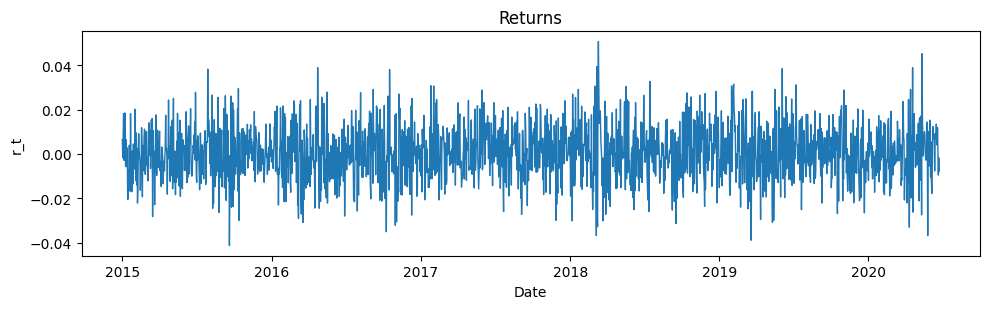

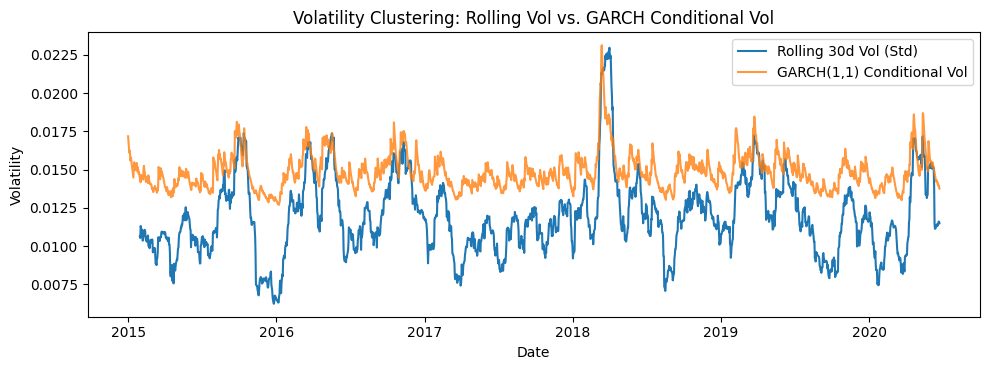

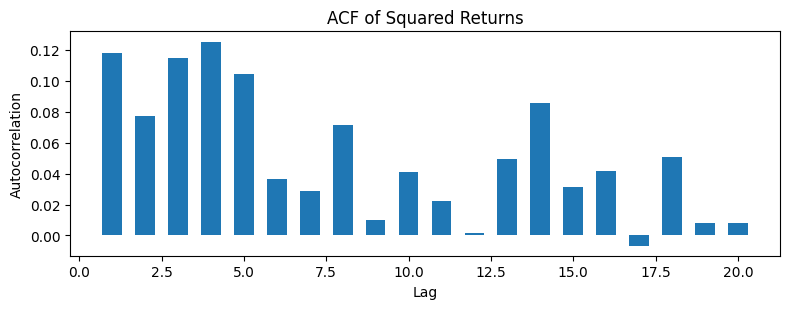

=== Volatility Clustering Study — Key Points ===
Convergence: True. Optimization terminated successfully
mu     =  0.000538
omega  =  0.00001476
alpha  =  0.0500
beta   =  0.9000
alpha+beta =  0.9500
Stationary (alpha+beta<1). Shock half-life ≈ 13.51 periods.

Interpretation:
- Significant alpha captures how new shocks (squared residuals) move volatility.
- High beta indicates strong persistence (volatility clusters over time).
- alpha+beta close to 1 implies slow decay of volatility after shocks (long memory-like).
- The ACF of squared returns typically shows positive autocorrelations at short lags when clustering is present.


In [ ]:
# Volatility Clustering Study with GARCH(1,1) 
# -------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)

# ----------------------
# 1) DATA
# ----------------------
USE_SIM = True

if USE_SIM:
    # Simulate T returns from a GARCH(1,1) to show volatility clustering
    T = 2000
    true_mu     = 0.0
    true_omega  = 0.000005   # long-run variance component
    true_alpha  = 0.07       # shock term (ARCH)
    true_beta   = 0.90       # persistence (GARCH)
    # Ensure stationarity: alpha + beta < 1
    assert true_alpha + true_beta < 1.0
    
    eps = np.zeros(T)
    h   = np.zeros(T)
    z   = np.random.randn(T)  # i.i.d. N(0,1)
    h0  = true_omega / (1 - true_alpha - true_beta)
    h[0] = h0
    eps[0] = np.sqrt(h[0]) * z[0]
    for t in range(1, T):
        h[t]   = true_omega + true_alpha * eps[t-1]**2 + true_beta * h[t-1]
        eps[t] = np.sqrt(h[t]) * z[t]
    
    r = true_mu + eps  # returns
    dates = pd.date_range("2015-01-01", periods=T, freq="D")
    returns = pd.Series(r, index=dates, name="r")
else:
    # Example: If you have your own returns series (in decimal, not %), set it here:
    # returns = your_returns_series.copy()
    raise ValueError("Set USE_SIM=True or provide your own 'returns' Series.")

# ----------------------
# 2) GARCH(1,1) MLE
# ----------------------
def garch11_negloglik(theta, r):
    """
    theta = [mu, omega, alpha, beta]
    r: 1D array of returns
    """
    mu, omega, alpha, beta = theta
    T = len(r)
    if omega <= 0 or alpha < 0 or beta < 0 or (alpha + beta) >= 0.999:
        return 1e12  # penalize invalid params
    
    eps = r - mu
    h = np.empty(T)
    # initialize h0 to unconditional variance (or sample variance fallback)
    try:
        h0 = omega / (1.0 - alpha - beta)
        if h0 <= 0 or not np.isfinite(h0):
            raise ValueError
    except Exception:
        h0 = np.var(eps)
        if h0 <= 0:
            h0 = 1e-6
    h[0] = h0
    
    for t in range(1, T):
        h[t] = omega + alpha * eps[t-1]**2 + beta * h[t-1]
        if h[t] <= 0 or not np.isfinite(h[t]):
            return 1e12
    
    # Gaussian log-likelihood
    ll = -0.5 * (np.log(2*np.pi) + np.log(h) + (eps**2)/h)
    # Return negative log-likelihood
    return -np.sum(ll)

# Initial guess
mu0    = float(np.mean(returns.values))
omega0 = np.var(returns.values) * 0.1
alpha0 = 0.05
beta0  = 0.90
x0 = np.array([mu0, omega0, alpha0, beta0], dtype=float)

# Bounds and constraints: omega>0, alpha>=0, beta>=0, alpha+beta<0.999
bounds = [(-1.0, 1.0), (1e-12, 10.0), (1e-12, 0.999), (1e-12, 0.999)]
cons = ({"type": "ineq", "fun": lambda th: 0.999 - (th[2] + th[3])},)

opt = minimize(
    garch11_negloglik, x0,
    args=(returns.values,),
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"maxiter": 500, "ftol": 1e-10, "disp": False}
)

mu_hat, omega_hat, alpha_hat, beta_hat = opt.x

# Recompute conditional variance series with estimated params
eps_hat = returns.values - mu_hat
h_hat = np.empty_like(eps_hat)
h0_hat = omega_hat / (1.0 - alpha_hat - beta_hat)
h_hat[0] = h0_hat
for t in range(1, len(returns)):
    h_hat[t] = omega_hat + alpha_hat * eps_hat[t-1]**2 + beta_hat * h_hat[t-1]

cond_vol = np.sqrt(h_hat)  # conditional volatility

# ----------------------
# 3) Simple Diagnostics & Stats
# ----------------------
def acf(x, nlags=20):
    """Simple autocorrelation function (unbiased) up to nlags (excluding lag 0)."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    var = np.dot(x, x)
    acf_vals = []
    for k in range(1, nlags+1):
        cov = np.dot(x[:-k], x[k:])
        acf_vals.append(cov / var)
    return np.array(acf_vals)

sq_returns = returns.values**2
acf_sq = acf(sq_returns, nlags=20)

alpha_plus_beta = alpha_hat + beta_hat
half_life = np.log(0.5) / np.log(alpha_plus_beta) if alpha_plus_beta < 1 else np.inf

summary = {
    "Converged": bool(opt.success),
    "Message": opt.message,
    "LogLik (neg)": float(opt.fun),
    "mu": float(mu_hat),
    "omega": float(omega_hat),
    "alpha": float(alpha_hat),
    "beta": float(beta_hat),
    "alpha+beta": float(alpha_plus_beta),
    "Half-life (days)": float(half_life),
}

# Display a tidy summary (optional: pretty print)
try:
    import caas_jupyter_tools  # present in some notebook environments
    import pandas as pd
    caas_jupyter_tools.display_dataframe_to_user("GARCH(1,1) Parameter Estimates & Stats", pd.DataFrame(summary, index=[0]))
except Exception:
    print("\n=== GARCH(1,1) Parameter Estimates & Stats ===")
    for k, v in summary.items():
        print(f"{k}: {v}")

# ----------------------
# 4) Plots
# ----------------------

# (A) Returns time series
plt.figure(figsize=(10, 3.2))
plt.plot(returns.index, returns.values, linewidth=1)
plt.title("Returns")
plt.xlabel("Date")
plt.ylabel("r_t")
plt.tight_layout()
plt.show()

# (B) Rolling volatility vs GARCH conditional volatility
roll_vol = returns.rolling(30).std().dropna()
plt.figure(figsize=(10, 3.8))
plt.plot(roll_vol.index, roll_vol.values, label="Rolling 30d Vol (Std)")
plt.plot(returns.index, cond_vol, alpha=0.8, label="GARCH(1,1) Conditional Vol")
plt.title("Volatility Clustering: Rolling Vol vs. GARCH Conditional Vol")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()

# (C) ACF of squared returns
lags = np.arange(1, len(acf_sq)+1)
plt.figure(figsize=(8, 3.2))
plt.bar(lags, acf_sq, width=0.6)
plt.title("ACF of Squared Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# ----------------------
# 5) Textual Interpretation (printed)
# ----------------------
print("=== Volatility Clustering Study — Key Points ===")
print(f"Convergence: {opt.success}. {opt.message}")
print(f"mu     = {mu_hat: .6f}")
print(f"omega  = {omega_hat: .8f}")
print(f"alpha  = {alpha_hat: .4f}")
print(f"beta   = {beta_hat: .4f}")
print(f"alpha+beta = {alpha_plus_beta: .4f}")
if alpha_plus_beta < 1:
    print(f"Stationary (alpha+beta<1). Shock half-life ≈ {half_life:.2f} periods.")
else:
    print("Non-stationary (alpha+beta≥1) — volatility is explosive/persistent.")

print("\nInterpretation:")
print("- Significant alpha captures how new shocks (squared residuals) move volatility.")
print("- High beta indicates strong persistence (volatility clusters over time).")
print("- alpha+beta close to 1 implies slow decay of volatility after shocks (long memory-like).")
print("- The ACF of squared returns typically shows positive autocorrelations at short lags when clustering is present.")
